# Améliorez un jeu de données

Dans ce chapitre nous allons travailler sur  le dataset des arbres de Paris qui contient des informations sur plus de 200 000 arbres sur Paris intra-muros et sa périphérie proche.

In [1]:
# importations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# chargement du dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/paris-arbres-clean-2023-09-10.csv"
)

# affichage d'un extrait
df.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14776\386170737.py:9: DtypeWarning: Columns (0: idbase, 1: numero) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,idbase,domanialite,arrondissement,complement_adresse,numero,lieu_adresse,idemplacement,libelle_francais,genre,espece,variete_oucultivar,circonference_cm,hauteur_m,stade_de_developpement,remarquable,geo_point_2d
0,256032,Alignement,PARIS 14E ARRDT,NaN,NaN,RUE VERCINGETORIX,000602025,Erable,Acer,pseudoplatanus,''Atropurpureum'',70.0,6.0,Jeune (arbre),NON,"48.83154687478726, 2.3093726893065596"
1,281618,Alignement,PARIS 8E ARRDT,NaN,NaN,AVENUE DES CHAMPS ELYSEES,000305044,Marronnier,Aesculus,hippocastanum,''Baumannii'',20.0,4.0,Jeune (arbre),NON,"48.86665704304558, 2.3162802812024443"
2,302647,Jardin,PARIS 8E ARRDT,Secteur Kiosque,NaN,JARDINS DES CHAMPS ELYSEES - ABORDS DU KIOSQUE...,000109003,If,Taxus,baccata,NaN,50.0,5.0,Jeune (arbre)Adulte,NON,"48.86594098488487, 2.3177825326579695"
3,238226,Alignement,PARIS 12E ARRDT,37,NaN,AVENUE DE SAINT MANDE,000501020,Platane,Platanus,x hispanica,NaN,30.0,5.0,Jeune (arbre),NON,"48.84515461889761, 2.4008303350818525"
4,110978,Jardin,PARIS 19E ARRDT,NaN,NaN,PARC DES BUTTES CHAUMONT,K69K0040,Pin,Pinus,nigra,NaN,100.0,10.0,NaN,NaN,"48.87971709048107, 2.3797109748696337"


## Repérez les données manquantes

In [2]:
# Limitons nous aux platanes
df = df[df.libelle_francais == "Platane"].copy()

In [3]:
# La variable  stade_de_developpement  a 3 350 valeurs manquantes (NaN).
df['stade_de_developpement'].value_counts(dropna=False)

stade_de_developpement
Adulte                 21620
Jeune (arbre)Adulte     8356
Jeune (arbre)           5916
NaN                     3350
Mature                  3346
Name: count, dtype: int64

On peut aussi essayer de remédier aux valeurs manquantes en observant la relation entre les mesures des arbres et leur stade de développement. Notre hypothèse est que les arbres  Jeune  ou  Mature  sont nettement plus petits que les arbres  Adulte  .

<Axes: xlabel='stade_de_developpement', ylabel='circonference_cm'>

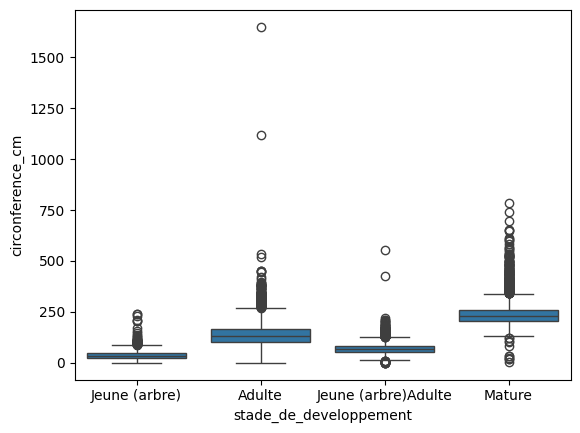

In [4]:
sns.boxplot(data=df, y="circonference_cm", x="stade_de_developpement")

<Axes: xlabel='stade_de_developpement', ylabel='hauteur_m'>

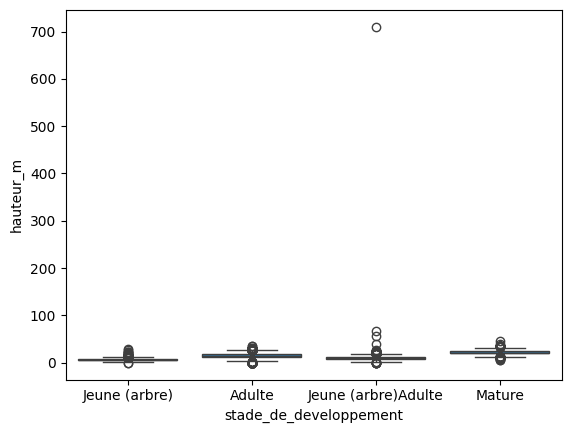

In [5]:
sns.boxplot(data=df, y="hauteur_m", x="stade_de_developpement")

Au vu des boxplots on peut établir les règles suivantes

In [6]:
cond1 = (
    (df.stade_de_developpement.isna())
    & (df.hauteur_m > 20)
    & (df.circonference_cm > 200)
)

cond2 = (
    (df.stade_de_developpement.isna()) & (df.hauteur_m < 8) & (df.circonference_cm < 50)
)

df[cond1].stade_de_developpement = "Mature"
df[cond2].stade_de_developpement = "Jeune (arbre)"

In [7]:

df.shape

(42588, 16)

## Détectez les outliers (données aberrantes)

Traçons par exemple la hauteur et la circonférence des platanes. On trouve un platane de 700 mètres de hauteur et 2 platanes de plus de 10 mètres de circonférence.

<Axes: xlabel='circonference_cm', ylabel='hauteur_m'>

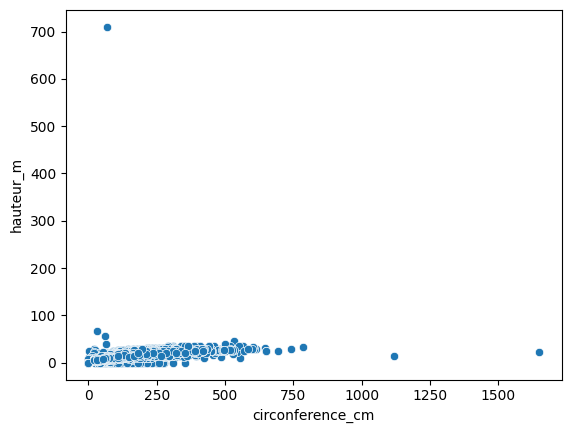

In [8]:
sns.scatterplot(data=df, x="circonference_cm",y="hauteur_m")

In [9]:
# On peut enlever ces 3 échantillons
df = df[(df.circonference_cm < 1000) & (df.hauteur_m < 100)].copy()

## méthode du z-score
Le z-score mesure de combien d'écarts types une valeur est éloignée de la moyenne de la variable. On considère qu'un z-score supérieur à 2 ou 3 correspond à un outlier.

In [10]:
from scipy import stats

df['z_circonference'] = stats.zscore(df['circonference_cm'])

df['z_hauteur'] = stats.zscore(df['hauteur_m'])

<Axes: xlabel='z_circonference', ylabel='Count'>

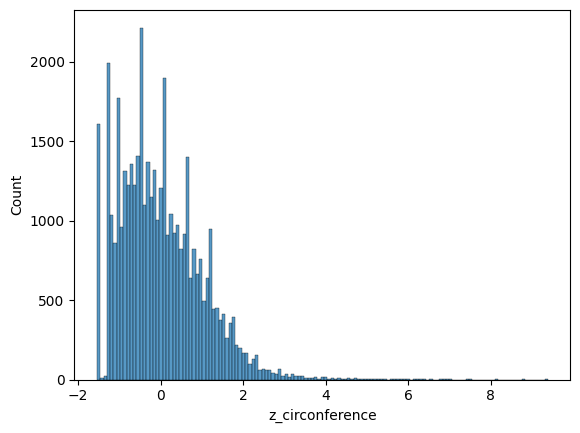

In [11]:
sns.histplot(x=df['z_circonference'])

<Axes: xlabel='z_hauteur', ylabel='Count'>

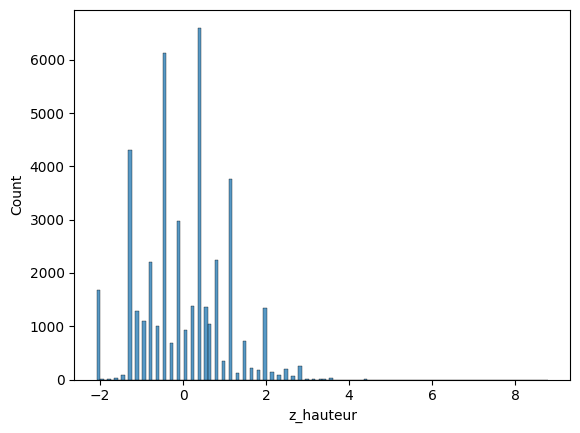

In [12]:
sns.histplot(x=df["z_hauteur"])

##  la méthode de l'IQR

L'IQR est la différence entre le 25e centile (Q1) et le 75e centile (Q3) des données. Les valeurs :

- inférieures à Q1 - 1,5 * IQR 

- ou supérieures à Q3 + 1,5 * IQR 

sont considérées comme aberrantes.

In [15]:
iqr = np.quantile(df['hauteur_m'],q=[0.25,0.75])

limite_basse = iqr[0] - 1.5 * (iqr[1]-iqr[0])

limite_haute = iqr[1] + 1.5 * (iqr[1] - iqr[0])

display(f"{limite_basse,limite_haute=}")

'limite_basse,limite_haute=(np.float64(-5.5), np.float64(30.5))'

Ce qui donne -5,5 pour la limite basse (pas très utile vu que les arbres n'ont pas de hauteur négative !) et 30,5 pour la limite haute. Plus intéressant. Pour la circonférence on obtient une limite haute à 305 cm.

Une fois identifiés, il peut y avoir plusieurs façons moins drastiques de traiter les outliers.

On citera :

- Prendre le log de la valeur.

- Instaurer une règle arbitraire

- Discrétiser la variable par intervalle en laissant le dernier intervalle ouvert pour inclure les valeurs extrêmes.

## Normalisez les valeurs numériques

Les 2 méthodes de  normalisation les plus courantes sont :

Min-Max Scaling (Normalisation).

Z-Score Standardization.